**Aims:** Extract results from the CRISPRi screen processing outputs and generate plots for the manuscript.

- [ ] A table of the V3 data including the parent veh vs DNAPKi, KO veh vs DNAPKi, and parent veh vs KO veh comparisons (Table S3) - I will use this to replot the stuff in Fig 5
- [ ] Some kind of QC plot for the V3 data - a PCA plot would be great if it looks okay and I'll put that in a supp figure

### Setup python session

In [1]:
# !pip uninstall -y screenpro2
# !pip install git+https://github.com/ArcInstitute/screenpro2.git@dev
# # !pip install ScreenPro2

In [2]:
from glob import glob

import numpy as np
import pandas as pd 
import anndata as ad
import scanpy as sc

import screenpro as scp
import blitzgsea as blitz

import matplotlib.pyplot as plt

In [3]:
import datetime

import matplotlib
import matplotlib.ticker as ticker

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import font_manager as fm
from matplotlib import rcParams, rc_context

from screenpro.plotting._utils import almost_black, dark2


matplotlib.use('cairo')

font_files = fm.findSystemFonts(fontpaths='/khayyam/abe/miniconda3/envs/screenpro2/fonts/', fontext='ttf')

for font_file in font_files:
    fm.fontManager.addfont(font_file)


# {f.name for f in matplotlib.font_manager.fontManager.ttflist}

rcParams['font.sans-serif'] = 'Helvetica'
rcParams['font.family'] = ['Helvetica']
rcParams['figure.dpi'] = 140

rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

In [4]:
drug_names = {
    'Pi': 'PARPi',
    'Ri': 'ATRi',
    'Wi': 'WEE1i',
    'Mi': 'ATMi',
    'Ki': 'DNAPKi',
    'PiRi': 'PARPi+ATRi',
    'PiWi': 'PARPi+WEE1i',
    'PiMi': 'PARPi+ATMi',
    'PiKi': 'PARPi+DNAPKi'
}

In [5]:
### get result tables: gene level scores with out negative controls
def getAnnotatedTables(screen, run_name, threshold):
    return dict([
        (phenotype_name, 
         screen.getPhenotypeScores(
             run_name=run_name,phenotype_name=phenotype_name,threshold=threshold, pvalue_col='ttest pvalue'
         ).reset_index().rename(columns={'index':'sgID_AB'}).set_index(
             ['sgID_AB','target','transcript'])
            )
        for phenotype_name in screen.listPhenotypeScores(run_name=run_name)
    ])


### get annotated result table: rho scores
def get_annotated_result_table(screen, run_name, name_it = '', threshold=6):
    return pd.concat(dict([
        # (drug_names[k.split(':')[1].split('_vs_')[0]],table) for k, table in 
        # (name_it + k.split(':')[1],table) for k, table in 
        (name_it + k,table) for k, table in 
        getAnnotatedTables(screen,threshold=threshold,run_name=run_name).items()
        # if 'rho' in k or 'gamma' in k
    ]),axis=1)

In [6]:
### pathway analysis
pager_dir = "/khayyam/abe/tools/pager/"
pager_annotation_path = '/khayyam/abe/tools/pager/annotations/human'

c5_gobp_gmt = blitz.enrichr.read_gmt(
    f'{pager_annotation_path}/msigdb_v7.4_c5.go.bp/c5.go.bp.v7.4.symbols.gmt'
)


def run_rho_gsea_directional(df,var_col,gmt,min_size=15,max_size=150):
    
    signature = df.query('target!="negative_control"')[var_col].reset_index().drop(
        columns=['transcript','sgID_AB']
    ).copy()

    result = blitz.gsea(
        signature=signature,
        library=gmt,
        min_size=min_size,
        max_size=max_size,
        verbose=True
    )
    
    return signature, result

___

### Load Data
Load Screen Processing guide level and gene level result tables.

In [7]:
crispri_v3_adata = sc.read_h5ad('../screens/A549_PRDX1_CRISPRi_v3.h5ad.gz')

In [8]:
crispri_v3_screen = scp.load._read_screen_pkl('../screens/A549_PRDX1_CRISPRi_v3_screens')

In [9]:
crispri_v3_screen.phenotypes.keys()

dict_keys(['compare_reps_parent', 'compare_reps_PRDX1KO', 'compare_reps_vehicle'])

___

In [10]:
# pd.concat(),axis=1).dropna()

In [11]:
crispri_v3_screen.phenotypes.keys()

dict_keys(['compare_reps_parent', 'compare_reps_PRDX1KO', 'compare_reps_vehicle'])

In [12]:
crispri_v3_screen_result_tables = pd.concat([
    get_annotated_result_table(
        crispri_v3_screen,run_name='compare_reps_PRDX1KO', name_it='PRDX1KO::'
    ),
    get_annotated_result_table(
        crispri_v3_screen,run_name='compare_reps_parent', name_it='parent::'
    ),

    get_annotated_result_table(
        crispri_v3_screen,run_name='compare_reps_vehicle', name_it='vehicle::'
    )
],axis=1).sort_index(level=[1], ascending=[True])

In [13]:
crispri_v3_screen_result_tables.columns.get_level_values(0).unique()

Index(['PRDX1KO::gamma:vehicle_vs_T0', 'PRDX1KO::tau:DNAPKi_vs_T0',
       'PRDX1KO::rho:DNAPKi_vs_vehicle', 'parent::gamma:vehicle_vs_T0',
       'parent::tau:DNAPKi_vs_T0', 'parent::rho:DNAPKi_vs_vehicle',
       'vehicle::gamma:parent_vs_T0', 'vehicle::tau:PRDX1KO_vs_T0',
       'vehicle::rho:PRDX1KO_vs_parent'],
      dtype='object')

In [14]:
# crispri_v3_screen_gsea_results = {}

# for comparison in crispri_v3_screen_result_tables.columns.get_level_values(0).unique():

#     if 'rho' in comparison:
#         print(comparison)
        
#         _, res = run_rho_gsea_directional(
#             crispri_v3_screen_result_tables[comparison].dropna(),
#             var_col='score', 
#             gmt=c5_gobp_gmt
#         )

#         crispri_v3_screen_gsea_results[comparison] = res

### PCA analysis

In [44]:
import plotnine as p9

In [15]:
def ggplot_pca(adata, figure_size=(3, 3), palette='Dark2'):
    # PCA plots
    pc_col_names = [
        "PC1 [" + str(round(adata.uns['pca']['variance_ratio'][0], 2) * 100) + "% variance]",
        "PC2 [" + str(round(adata.uns['pca']['variance_ratio'][1], 2) * 100) + "% variance]"
    ]

    df_pca = pd.concat([
            pd.DataFrame(adata.obsm['X_pca'][:,0:2], columns=pc_col_names),
            adata.obs.reset_index(drop=True)
        ],axis=1)

    p_pca = (
        p9.ggplot(df_pca, p9.aes(pc_col_names[0], pc_col_names[1]))
        + p9.geom_point(p9.aes(color="treatment"), alpha=0.6, size=5)
        # + p9.lims(
        #     x=(-50, 50),
        #     y=(-50, 50)
        # )
        + p9.scale_color_brewer('qualitative', palette=palette)
        + p9.theme(
            panel_background=p9.element_blank(),
            panel_grid=p9.element_blank(),
            # add axis lines
            axis_line=p9.element_line(color=almost_black, size=0.5),
            axis_text=p9.element_text(size=9,margin={"t": 5, "r": 5}),
            # remove legend title
            legend_title=p9.element_blank(),
            figure_size=figure_size
        )
    )

    return p_pca

In [95]:
pdata_list = []

crispri_v3_screen_parents = crispri_v3_screen.copy()
crispri_v3_screen_parents.adata = crispri_v3_screen_parents.adata[crispri_v3_screen_parents.adata.obs.cell_line.eq('parent')].copy()
crispri_v3_screen_parents.phenotypes['compare_reps'] = crispri_v3_screen_parents.phenotypes['compare_reps_parent']
crispri_v3_screen_parents.buildPhenotypeData(run_name='compare_reps', db_rate_col=None)
crispri_v3_screen_parents.pdata.obs['screen'] = 'parent'

pdata_list.append(crispri_v3_screen_parents.pdata)

crispri_v3_screen_prdx1ko = crispri_v3_screen.copy()
crispri_v3_screen_prdx1ko.adata = crispri_v3_screen_prdx1ko.adata[crispri_v3_screen_prdx1ko.adata.obs.cell_line.eq('PRDX1KO')].copy()
crispri_v3_screen_prdx1ko.phenotypes['compare_reps'] = crispri_v3_screen_prdx1ko.phenotypes['compare_reps_PRDX1KO']
crispri_v3_screen_prdx1ko.buildPhenotypeData(run_name='compare_reps', db_rate_col=None)
crispri_v3_screen_prdx1ko.pdata.obs['screen'] = 'PRDX1KO'

pdata_list.append(crispri_v3_screen_prdx1ko.pdata)

# crispri_v3_screen_vehicle = crispri_v3_screen.copy()
# crispri_v3_screen_vehicle.adata = crispri_v3_screen_vehicle.adata[crispri_v3_screen_vehicle.adata.obs.condition.eq('vehicle')].copy()
# crispri_v3_screen_vehicle.phenotypes['compare_reps'] = crispri_v3_screen_vehicle.phenotypes['compare_reps_vehicle']
# crispri_v3_screen_vehicle.buildPhenotypeData(run_name='compare_reps', db_rate_col=None)

# pdata_list.append(crispri_v3_screen_vehicle.pdata)

combined_pdata = ad.concat(pdata_list,axis=0)

/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [108]:
crispri_v3_screen_vehicle.listPhenotypeScores(run_name='compare_reps_vehicle')

['gamma:parent_vs_T0', 'tau:PRDX1KO_vs_T0', 'rho:PRDX1KO_vs_parent']

In [118]:
crispri_v3_screen_vehicle = crispri_v3_screen.copy()
crispri_v3_screen_vehicle.adata = crispri_v3_screen_vehicle.adata[crispri_v3_screen_vehicle.adata.obs.condition.isin(['vehicle','T0'])].copy()
crispri_v3_screen_vehicle.adata = crispri_v3_screen_vehicle.adata[~(crispri_v3_screen_vehicle.adata.obs['cell_line'].eq('PRDX1KO')&crispri_v3_screen_vehicle.adata.obs['condition'].eq('T0'))].copy()

crispri_v3_screen_vehicle.phenotypes['compare_reps'] = crispri_v3_screen_vehicle.phenotypes['compare_reps_vehicle']
crispri_v3_screen_vehicle.buildPhenotypeData(run_name='compare_reps', db_rate_col=None)

pdata_list.append(crispri_v3_screen_vehicle.pdata)

ValueError: Length of values (0) does not match length of index (64237)

In [96]:
combined_pdata.obs['replicate'] = combined_pdata.obs.index.str[-1]#.astype(int)
combined_pdata.obs['score_tag'] = combined_pdata.obs.index.str.split('::').str[0].str.split(':').str[0]
combined_pdata.obs['treatment'] = combined_pdata.obs['screen'] + '__' + combined_pdata.obs.index.str.split('::').str[0].str.split(':').str[1]

In [97]:
combined_pdata = combined_pdata[combined_pdata.obs.score_tag.eq('rho')].copy()

/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [98]:
sc.pp.pca(combined_pdata)

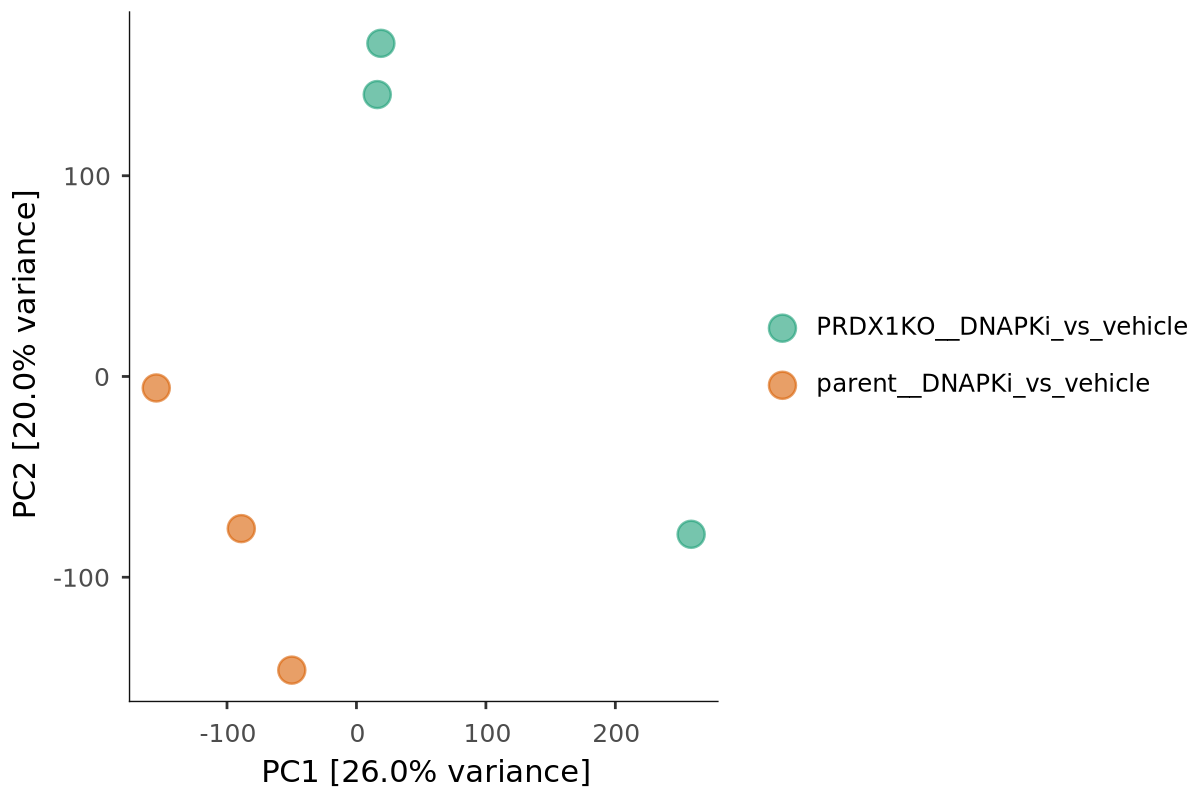

In [100]:
ggplot_pca(combined_pdata, figure_size=(6,4), palette='Dark2')

### save to file

? how we want to organize the results for the manuscript tables (!)

In [19]:
# with pd.ExcelWriter('CRISPRi-PRDX1-DDRi-screens.xlsx', engine='openpyxl') as writer:
#     screen.adata.obs.to_excel(writer, sheet_name='sample sheet')
#     screen.adata.to_df(layer='raw_counts').astype(int).T.to_excel(writer, sheet_name='raw counts')
#     screen.adata.to_df(layer='seq_depth_norm').astype(int).T.to_excel(writer, sheet_name='normalized counts')
#     getAnnotatedTable(screen_parent, threshold=2).to_excel(writer, sheet_name='parent screen')
#     getAnnotatedTable(screen_PRDX1KO, threshold=2).to_excel(writer, sheet_name='PRDX1KO screen')
#     getAnnotatedTable(screen_vehicle, threshold=2)[['rho:PRDX1KO_vs_parent']].to_excel(writer, sheet_name='vehicle screen')

Table S3

In [20]:
# with pd.ExcelWriter('tables/Table-S3.xlsx', engine='openpyxl') as writer:
#     crispri_v3_screen_result_tables.to_excel(writer, sheet_name='Gene Level Phenotypes')
#     # pd.concat(crispri_v3_screen_gsea_results,axis=1).to_excel(writer, sheet_name='GO GSEA Analysis')

# 

In [21]:
%reload_ext watermark

In [22]:
%watermark

Last updated: 2025-08-05T02:34:17.847089-07:00

Python implementation: CPython
Python version       : 3.12.0
IPython version      : 9.4.0

Compiler    : GCC 12.3.0
OS          : Linux
Release     : 5.15.0-131-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 56
Architecture: 64bit



In [23]:
%watermark --iversions

pandas    : 2.3.1
matplotlib: 3.10.3
screenpro : 0.5.1
blitzgsea : 1.3.54
anndata   : 0.12.1
numpy     : 1.26.4
scanpy    : 1.11.3



___